### notes asf
- to inspect: `import inspect` then new line `print(inspect.signature(ellipsoid.normal_gravity))`
- restart the kernel to change region

Gravity disturbances are the differences between the measured gravity and a reference (normal) gravity produced by an ellipsoid. The disturbances are what allows geoscientists to infer the internal structure of the Earth.

In [32]:
import pygmt
import xarray as xr
import boule as bl
import verde as vd
import numpy as np
import pandas as pd
import pygmt

In [33]:
df = pd.read_csv("..\\..\\data\\Canada_Gravity_2018.csv")
print(df.head())

            X          Y       ADJG  B_ERR  BOUGUER  COORD_ERR         DAY  \
0 -129.323416  46.595778  980761.71   3.74   182.17      200.0  2-Jul-1983   
1 -129.345405  46.595778  980758.94   3.74   179.20      200.0  2-Jul-1983   
2 -129.366401  46.596767  980759.17   3.74   179.54      200.0  2-Jul-1983   
3 -129.388405  46.597767  980760.00   3.72   179.39      200.0  2-Jul-1983   
4 -129.410409  46.599767  980761.03   3.71   179.55      200.0  2-Jul-1983   

    DEPTH  DEPTH_ERR  DEPTH_TYPE  ...  FA_ERR  FREEAIR  G_ERR     PROJ  \
0  2682.0       53.6           2  ...    0.61    -2.59    0.5  1983110   
1  2679.0       53.6           2  ...    0.61    -5.36    0.5  1983110   
2  2682.0       53.6           2  ...    0.61    -5.22    0.5  1983110   
3  2669.0       53.4           2  ...    0.61    -4.48    0.5  1983110   
4  2659.0       53.2           2  ...    0.61    -3.63    0.5  1983110   

   STATUS    STN  STN_TYPE   TC  TC_ERR  TIME  
0       1  12236        21  0.0     0.

In [34]:
df = df[["X", "Y", "ADJG"]]

# df["date"] = pd.to_datetime(df[["year", "month", "day"]])
# df = df.sort_values("date")
# df = df.drop_duplicates(
#     subset=["station_name"], keep="last")

# print(f'longitude min: {df["longitude"].min()}, longitude max: {df["longitude"].max()}')
# print(f'latitude min: {df["latitude"].min()}, latitude max: {df["latitude"].max()}')
print(f'longitude min: {df["X"].min()}, longitude max: {df["X"].max()}')
print(f'latitude min: {df["Y"].min()}, latitude max: {df["Y"].max()}')

print(f'Organized dataframe: \n{df.head()}')

longitude min: -130.999908, longitude max: -122.001396
latitude min: 46.587769, latitude max: 52.679476
Organized dataframe: 
            X          Y       ADJG
0 -129.323416  46.595778  980761.71
1 -129.345405  46.595778  980758.94
2 -129.366401  46.596767  980759.17
3 -129.388405  46.597767  980760.00
4 -129.410409  46.599767  980761.03


Now we adjust the min/max of long/lat based on region of interest.
- the inner df["##"] > ## is a boolean series, the outer df[...] is boolean indexing

In [35]:
# # df = df[df["longitude"] < -124] 
# # df = df[df["latitude"] > 47]

# print(f'adjusted longitude min: {df["longitude"].min()}, and max: {df["longitude"].max()}')
# print(f'adjusted latitude min: {df["latitude"].min()}, and max: {df["latitude"].max()}')

pygmt options:
- xyz2grd
- surface: interpolates a continuous grid from blockmean averaged points using splines in tension
    - From claude: *A regular spline tries to fit the smoothest possible curve through your data points, but "smoothest" can cause it to oscillate wildly between points. Adding tension pulls the surface taut which suppresses those oscillations.*
        - *More tension = flatter/stiffer between points, less tension = smoother but potentially more overshoot.*
- blockmean: averages multiple data points that fall within the same grid cell

In [36]:
# df_mean = pygmt.blockmean(
#     data=df[["longitude", "latitude", "Free_air_anom_terr_corr"]],
#     spacing=0.08,
#     region=[df["longitude"].min(), df["longitude"].max(), df["latitude"].min(), df["latitude"].max()]
# )

# # print(f'df_mean header: \n{df_mean.head()}')

# grid = pygmt.surface(
#     data=df_mean,
#     spacing=0.08,
#     region=[df["longitude"].min(), df["longitude"].max(), df["latitude"].min(), df["latitude"].max()]

# )
# # print(f'grid header: \n{grid.head()}')

vanc_region = [df["X"].min(), df["X"].max(), df["Y"].min(), df["Y"].max()]

df_mean = pygmt.blockmean(
    data=df[["X", "Y", "ADJG"]],
    spacing=0.01,
    region=vanc_region
)

# print(f'df_mean header: \n{df_mean.head()}')

grid = pygmt.surface(
    data=df_mean,
    spacing=0.01,
    region=vanc_region

)
# print(f'grid header: \n{grid.head()}')

blockmean [WARNING]: (x_max-x_min) must equal (NX + eps) * x_inc), where NX is an integer and |eps| <= 0.0001.


blockmean [WARNING]: (y_max-y_min) must equal (NY + eps) * y_inc), where NY is an integer and |eps| <= 0.0001.
blockmean (gmtapi_init_grdheader): Please select compatible -R and -I values
surface [WARNING]: (x_max-x_min) must equal (NX + eps) * x_inc), where NX is an integer and |eps| <= 0.0001.
surface [WARNING]: (y_max-y_min) must equal (NY + eps) * y_inc), where NY is an integer and |eps| <= 0.0001.
surface (gmtapi_init_grdheader): Please select compatible -R and -I values
surface [WARNING]: (x_max-x_min) must equal (NX + eps) * x_inc), where NX is an integer and |eps| <= 0.0001.
surface [WARNING]: (y_max-y_min) must equal (NY + eps) * y_inc), where NY is an integer and |eps| <= 0.0001.
surface (gmtapi_init_grdheader): Please select compatible -R and -I values


trouble shooting...

In [37]:
# print(grid.coords)
# print(grid.dims)

# grid_t = grid.transpose("x", "y")

# # print(f'after transposing... \n {grid_t.coords}')
# # print(grid_t.dims)

# grid_rename = grid.rename({"x": "longitude", "y": "latitude"})

# print(f'after renaming... \n {grid_rename.coords}')

In [38]:
pygmt.set_display(method="notebook")

(from claude) Line by line:

- **`pygmt.Figure()`** — creates a blank figure object
- **`fig.grdimage(grid_rename, ...)`** — plots the grid as a colored raster image
  - `projection="M20c"` — Mercator projection, 20cm wide
  - `cmap="viridis"` — color palette
- **`fig.basemap(frame=["af", "WEsn"])`** — adds the map frame/border
  - `"af"` — auto ticks with frame
  - `"WEsn"` — which sides get labels (West, East, South, north without label)
- **`fig.colorbar(...)`** — adds a colorbar
  - `position="JCB+w10c"` — centered below the map, 10cm wide
  - the frame labels are still set to `"mGal"` and `"observed gravity"` — you should update those to match your data (deflection of vertical in arcseconds)
- **`fig.coast(...)`** — overlays coastlines
  - `resolution="c"` — coarse resolution (fine for regional maps)
  - `area_thresh=1e4` — ignores small features under 10,000 km²
- **`fig.show()`** — renders and displays the figure

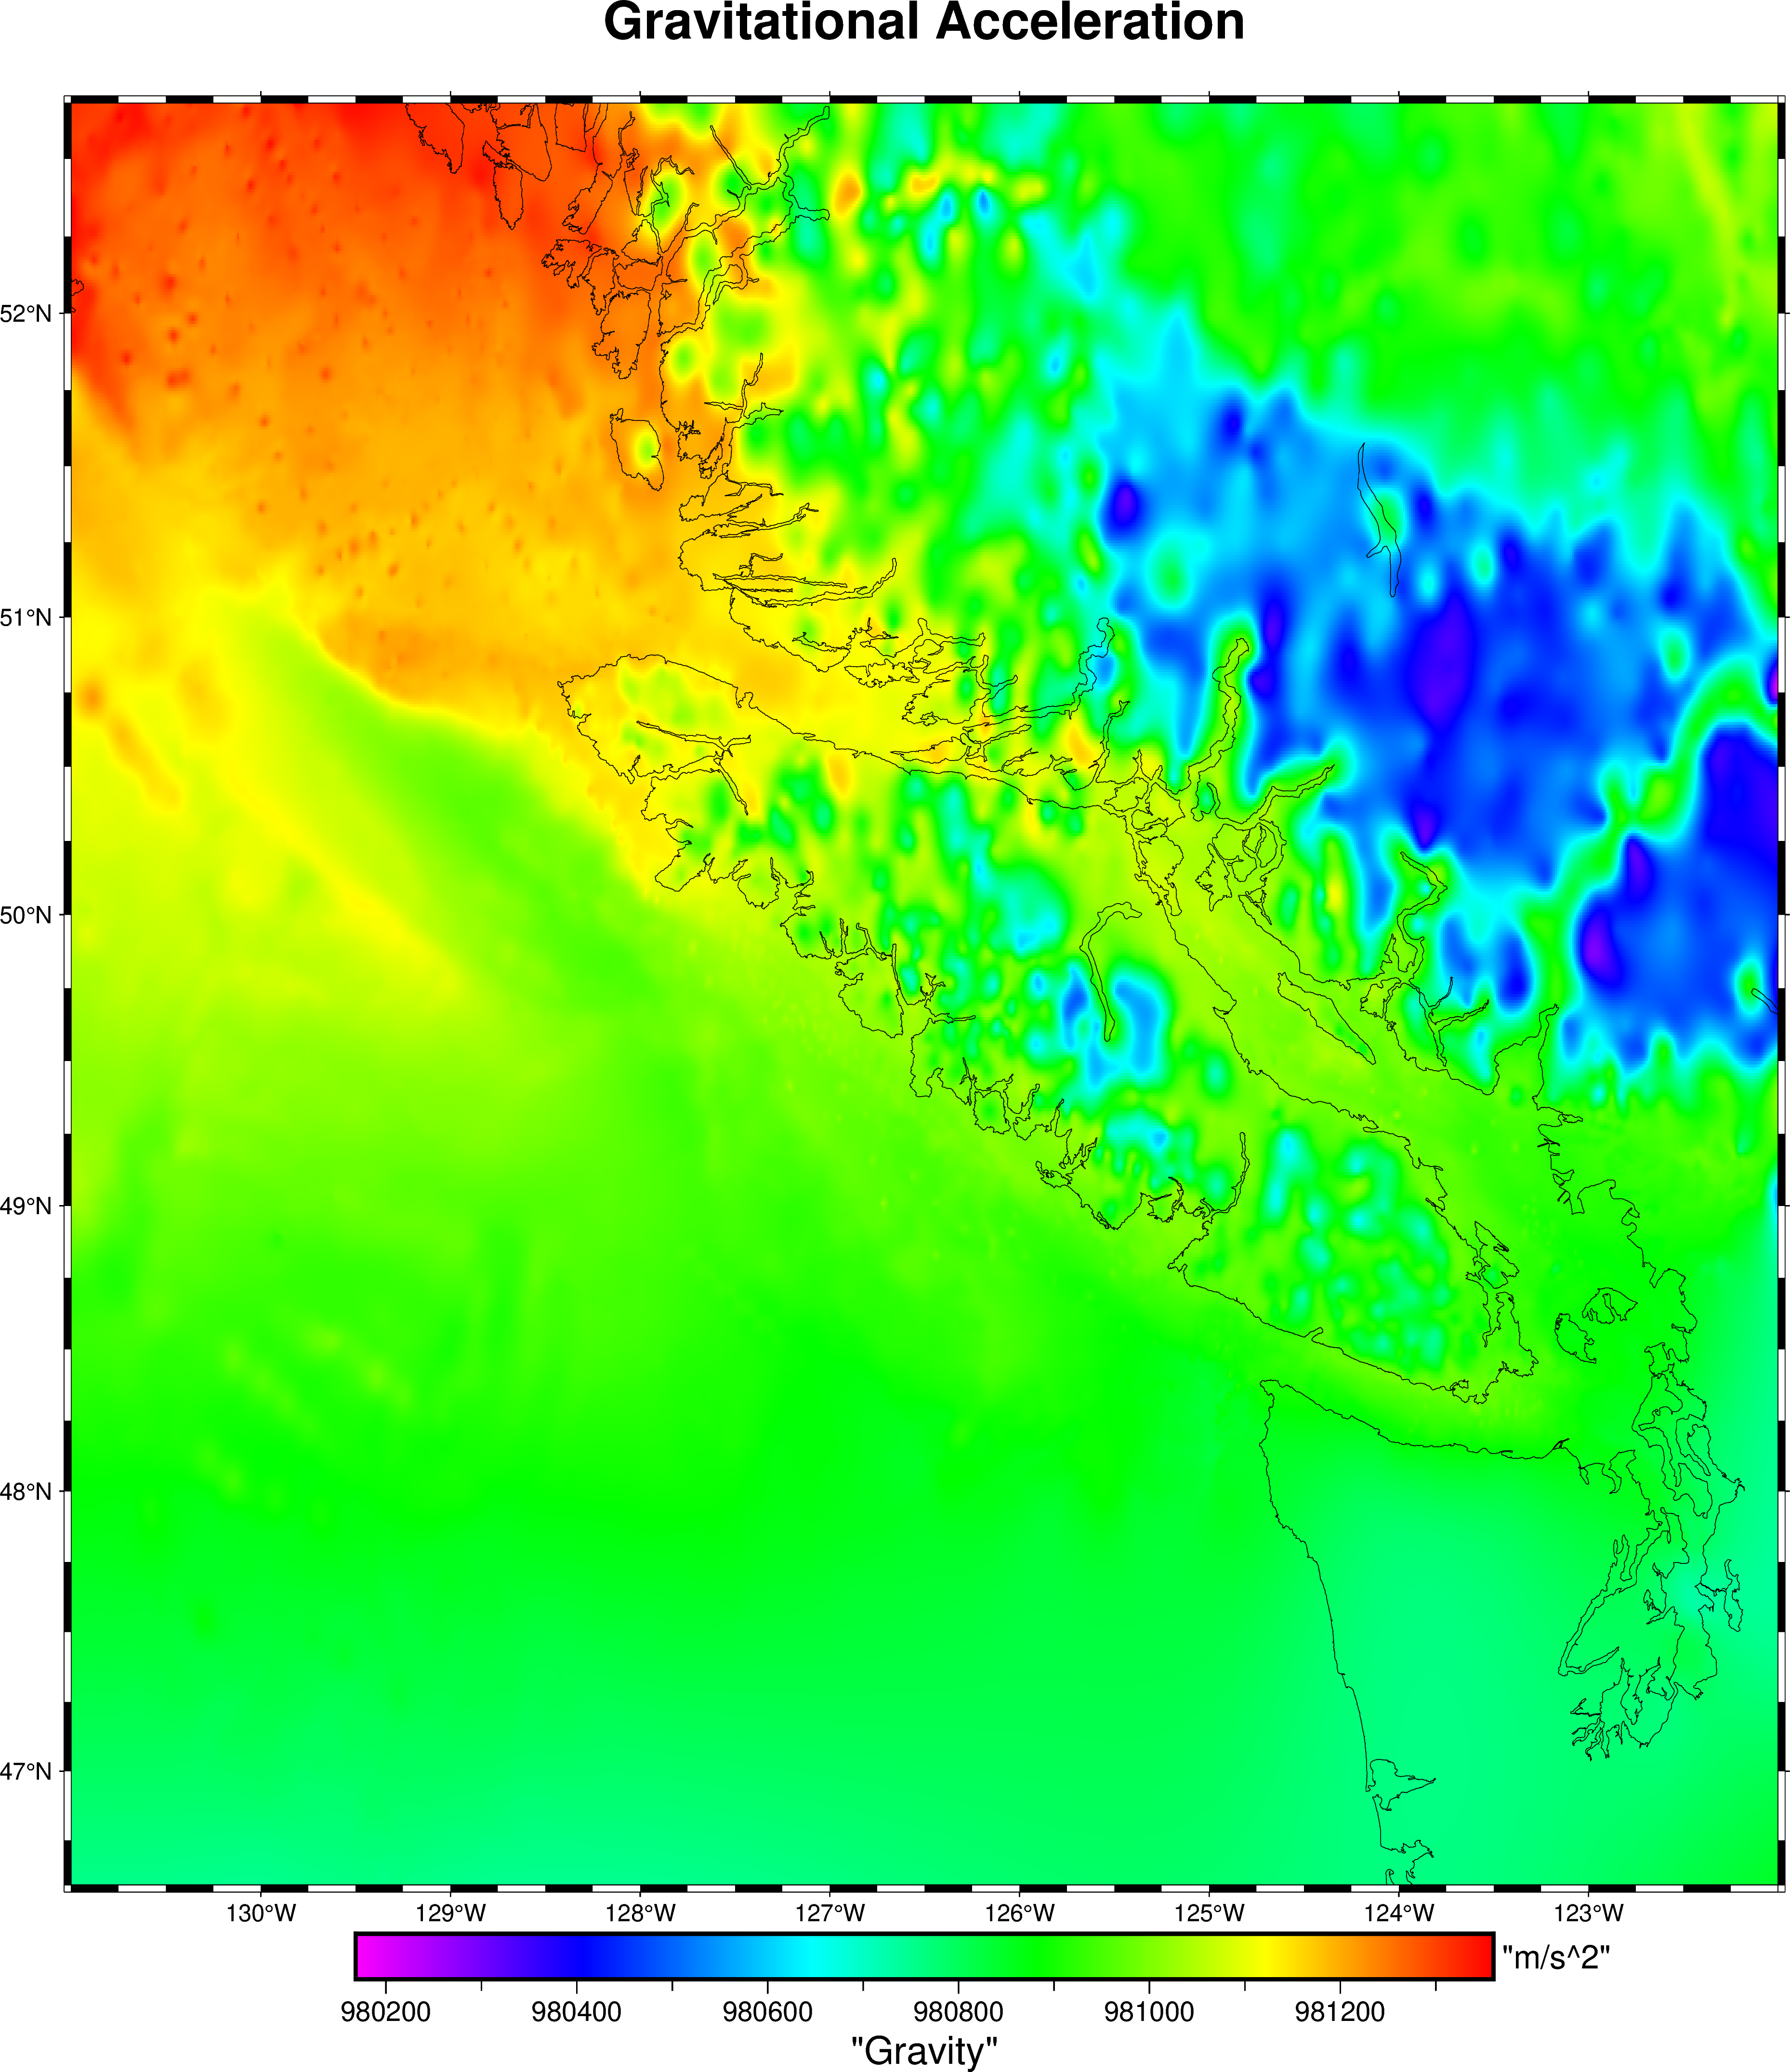

In [39]:
fig = pygmt.Figure()

fig.grdimage(
    grid,
    projection="M30c",
    cmap="rainbow")

fig.basemap(frame=["af", "+tGravitational Acceleration"])

fig.colorbar(
    position="JCB+w20c",
    frame=["af", 'y+l"m/s^2"', 'x+l"Gravity"'],
)

fig.coast(shorelines=True, resolution="f", area_thresh=1e2)

fig.savefig("../../figures/csv_data.png", dpi=400)
fig.show()

In [41]:
relief_grid = pygmt.datasets.load_earth_relief(
    resolution="30s", region=vanc_region, registration="gridline"
)

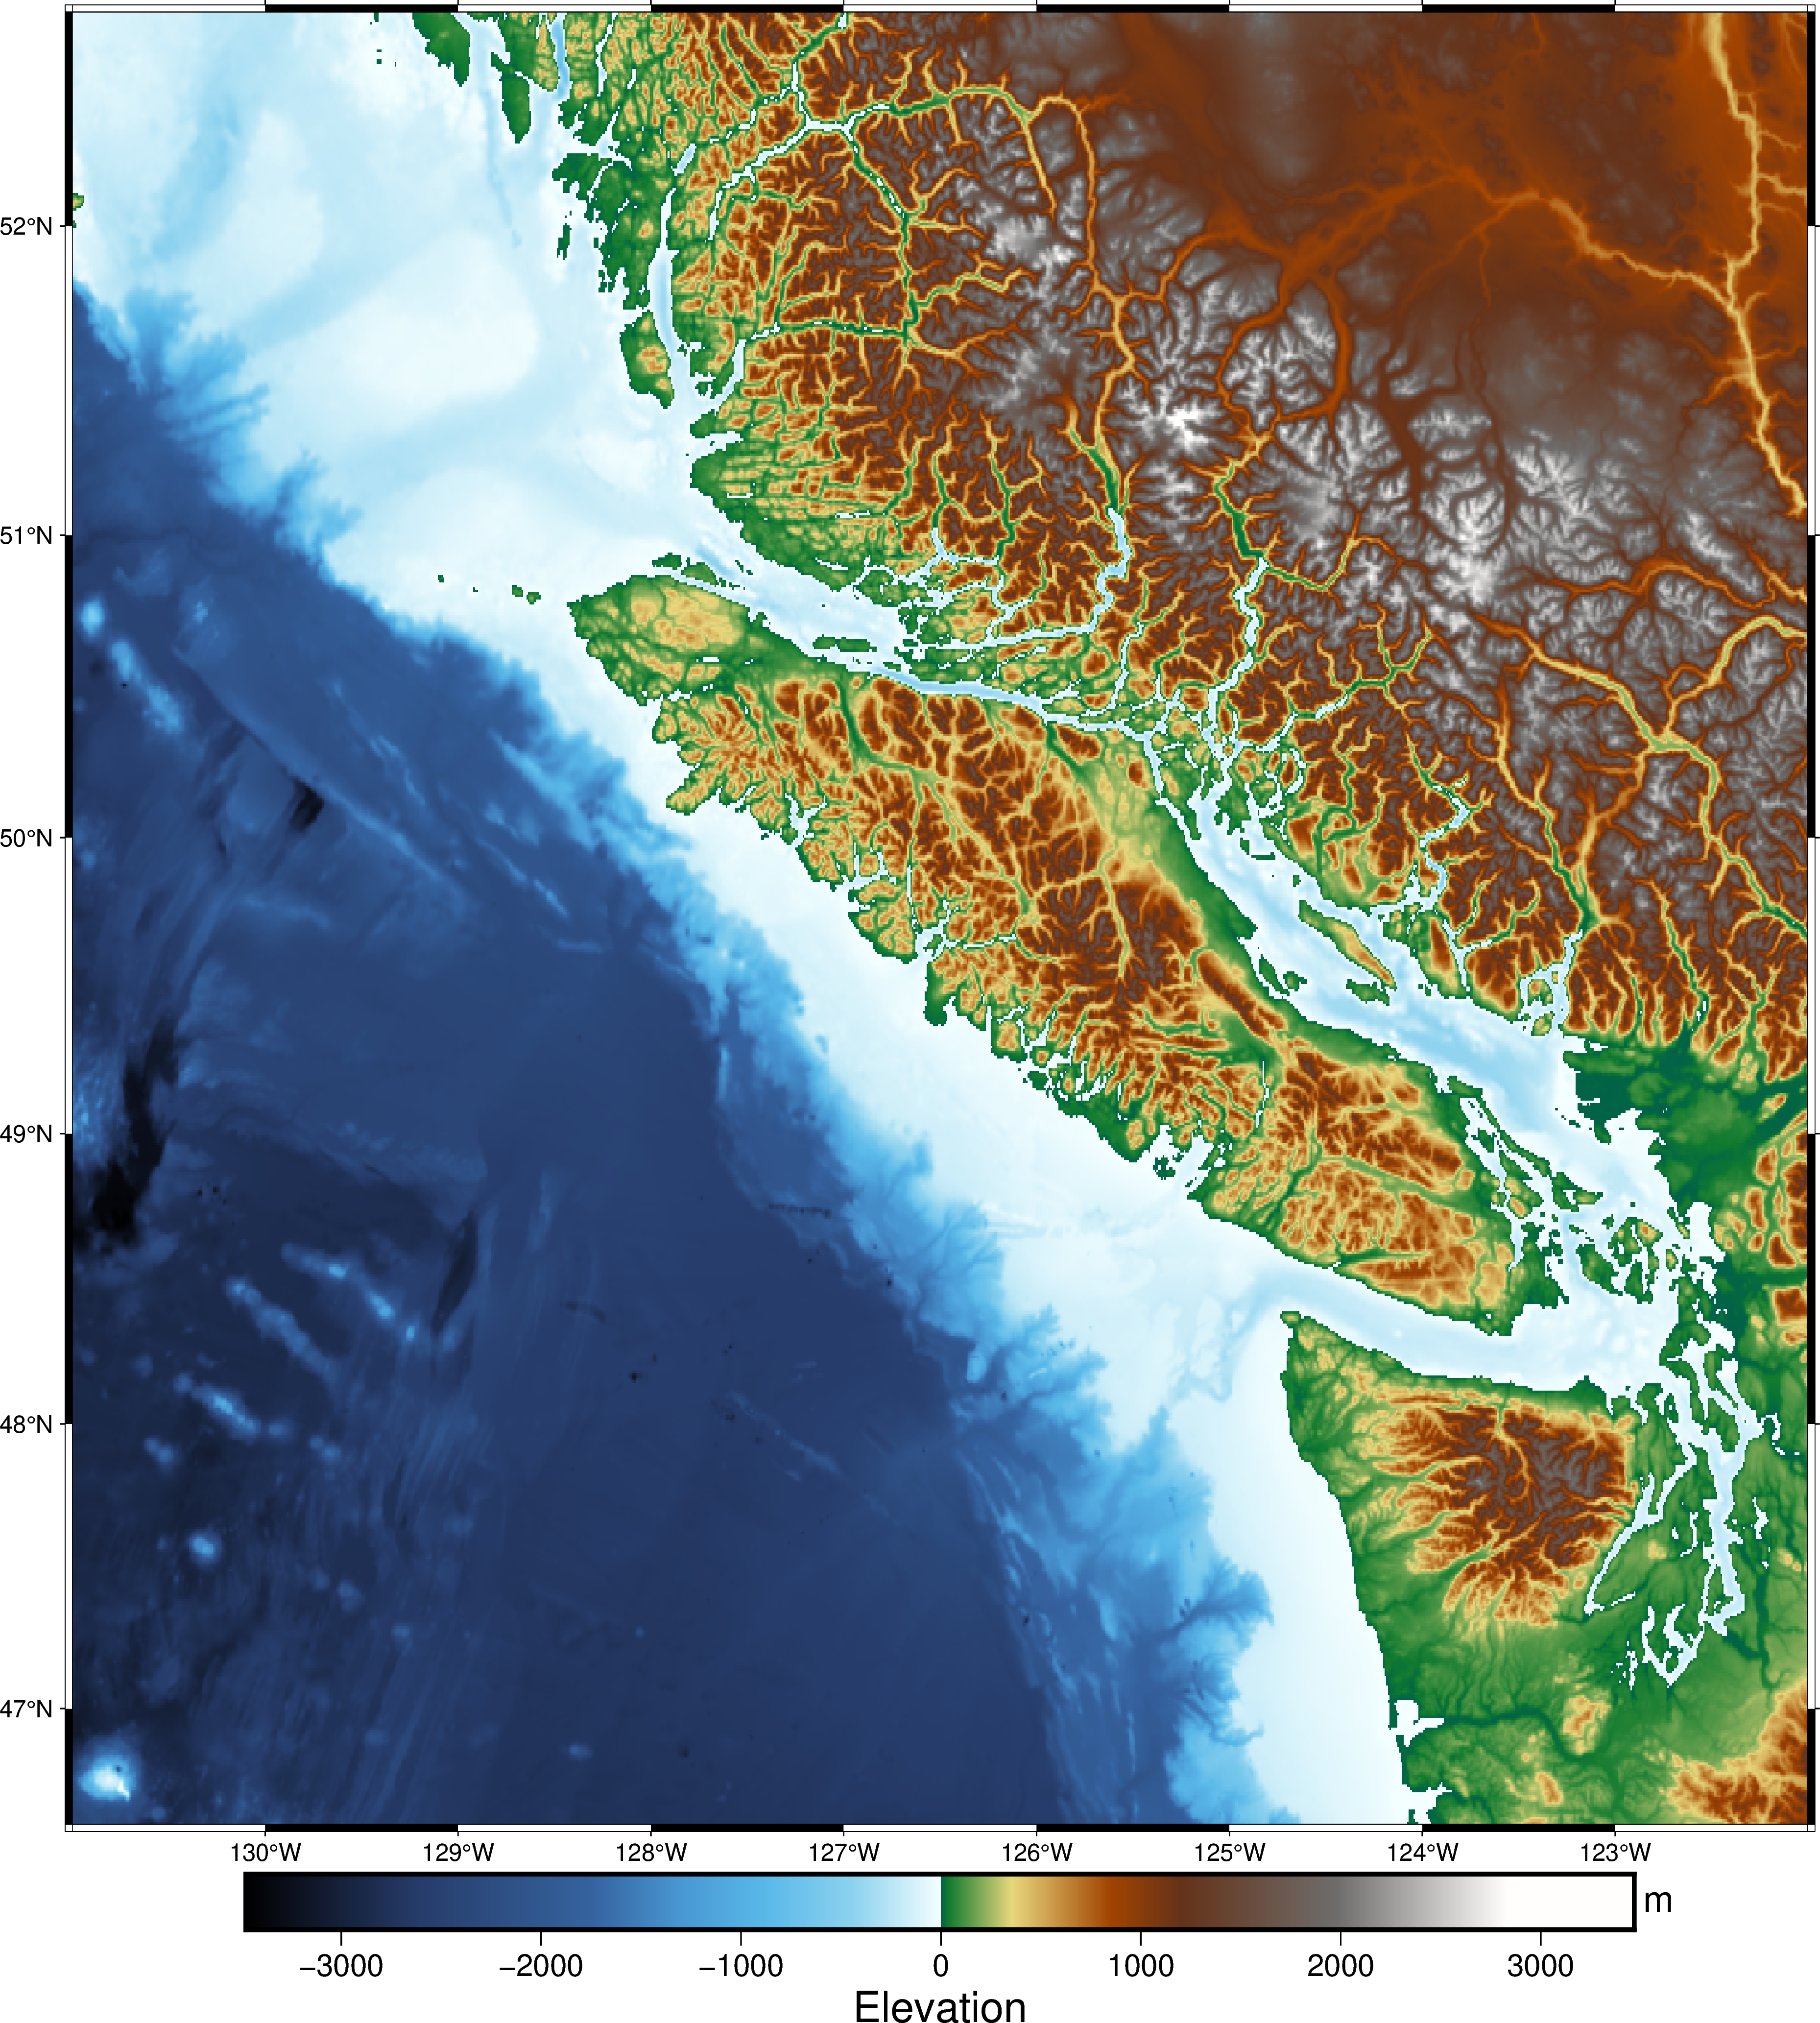

In [43]:
fig = pygmt.Figure()

fig.grdimage(
    relief_grid,
    frame="a",
    projection="M30c",
    cmap="geo")

fig.colorbar(frame=["a1000", "x+lElevation", "y+lm"])

fig.show()

In [51]:
relief_df = relief_grid.to_dataframe().reset_index()
relief_df.columns = ["latitude", "longitude", "elevation"]
relief_df.to_csv("../../created_data/relief_vanc.csv", index=False)